<a href="https://colab.research.google.com/github/hadri1-bisch/real-data-proect/blob/main/Copie_de_real_data_hotel_nuit%C3%A9e_HESTA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

df HESTA provenances avec les principales villes suisse a analyser


In [44]:
!pip install pxweb


In [45]:
import requests
import pandas as pd

In [46]:
url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

In [47]:
data = {
  "query": [
    {
      "code": "Monat",
      "selection": {
        "filter": "item",
        "values": ["1"]
      }
    },
    {
      "code": "Gemeinde",
      "selection": {
        "filter": "item",
        "values": ["5586"]
      }
    },
    {
      "code": "Herkunftsland",
      "selection": {
        "filter": "item",
        "values": ["1"]
      }
    }
  ],
  "response": {
    "format": "csv"
  }
}

In [48]:
r = requests.post(url, json=data)

print(r.status_code)
print(r.text[:200])

200
"Année","Mois","Commune","Suisse Arrivées","Suisse Nuitées"
"2013","Janvier","Lausanne",8444,16799
"2014","Janvier","Lausanne",11014,20580
"2015","Janvier","Lausanne",10674,19573
"2016","Janvier",


In [49]:
from io import StringIO

df = pd.read_csv(StringIO(r.text))

df.head()

,Année,Mois,Commune,Suisse Arrivées,Suisse Nuitées
0,2013,Janvier,Lausanne,8444,16799
1,2014,Janvier,Lausanne,11014,20580
2,2015,Janvier,Lausanne,10674,19573
3,2016,Janvier,Lausanne,12615,23279
4,2017,Janvier,Lausanne,12412,24540


AJOUTER 2025??????

In [50]:
years = [
"2015","2016","2017","2018","2019",
"2022","2023","2024", "2025"
]

In [51]:
communes = {
"261": "Zürich",
"3856": "Interlaken",
"3866": "Matten bei Interlaken",
"1061": "Luzern",
"2701": "Basel",
"3203": "St Gallen",
"3786": "St Moritz",
"3851": "Davos",
"5113": "Locarno",
"5586": "Lausanne",
"5661": "Château-d'Oex",
"5886": "Montreux",
"6024": "Nendaz",
"6288": "Saas-Fee",
"6290": "Zermatt",
"6621": "Genève"
}

pour gérer le crash out

In [52]:
import requests
import pandas as pd
from io import StringIO
import time

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

dfs = []

for code, name in communes.items():

    print("Téléchargement :", name)

    data = {
      "query": [

        {
          "code": "Jahr",
          "selection": {
            "filter": "item",
            "values": years
          }
        },

        {
          "code": "Monat",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        },

        {
          "code": "Gemeinde",
          "selection": {
            "filter": "item",
            "values": [code]
          }
        },

        {
          "code": "Herkunftsland",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        }

      ],

      "response": {
        "format": "csv"
      }

    }

    success = False
    attempts = 0

    while not success and attempts < 5:

        try:

            r = requests.post(url, json=data, timeout=120)

            df = pd.read_csv(StringIO(r.text))

            df["Commune_nom"] = name

            dfs.append(df)

            success = True

            # sauvegarde intermédiaire
            df_temp = pd.concat(dfs, ignore_index=True)
            df_temp.to_csv("tourisme_backup.csv", index=False)

            print("✔ Sauvegarde effectuée")

        except Exception as e:

            attempts += 1
            print("Erreur → retry", attempts)
            time.sleep(5)

    if not success:
        print("⚠️ Impossible de télécharger :", name)

df = pd.concat(dfs, ignore_index=True)

# sauvegarde finale
df.to_csv("tourisme_final.csv", index=False)

print("Téléchargement terminé")
print(df.shape)

Téléchargement : Zürich
✔ Sauvegarde effectuée
Téléchargement : Interlaken
✔ Sauvegarde effectuée
Téléchargement : Matten bei Interlaken
✔ Sauvegarde effectuée
Téléchargement : Luzern
✔ Sauvegarde effectuée
Téléchargement : Basel
✔ Sauvegarde effectuée
Téléchargement : St Gallen
✔ Sauvegarde effectuée
Téléchargement : St Moritz
✔ Sauvegarde effectuée
Téléchargement : Davos
✔ Sauvegarde effectuée
Téléchargement : Locarno
✔ Sauvegarde effectuée
Téléchargement : Lausanne
✔ Sauvegarde effectuée
Téléchargement : Château-d'Oex
✔ Sauvegarde effectuée
Téléchargement : Montreux
✔ Sauvegarde effectuée
Téléchargement : Nendaz
✔ Sauvegarde effectuée
Téléchargement : Saas-Fee
✔ Sauvegarde effectuée
Téléchargement : Zermatt
✔ Sauvegarde effectuée
Téléchargement : Genève
✔ Sauvegarde effectuée
Téléchargement terminé
(1404, 151)


inutile car pas de crassh out mais a garder pour code source

In [53]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.pxweb.bfs.admin.ch/api/v1/fr/px-x-1003020000_101/px-x-1003020000_101.px"

dfs = []

for code, name in communes.items():

    data = {
      "query": [

        {
          "code": "Jahr",
          "selection": {
            "filter": "item",
            "values": years
          }
        },

        {
          "code": "Monat",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        },

        {
          "code": "Gemeinde",
          "selection": {
            "filter": "item",
            "values": [code]
          }
        },

        {
          "code": "Herkunftsland",
          "selection": {
            "filter": "all",
            "values": ["*"]
          }
        }

      ],

      "response": {
        "format": "csv"
      }

    }

    r = requests.post(url, json=data)

    df = pd.read_csv(StringIO(r.text))

    df["Commune_nom"] = name

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

In [54]:

print(df.head())
print(df.shape)


    Année              Mois Commune  Pays de provenance - total Arrivées  \
0  2015.0  Total de l'année  Zürich                            1623691.0   
1  2015.0           Janvier  Zürich                             105949.0   
2  2015.0           Février  Zürich                             100500.0   
3  2015.0              Mars  Zürich                             122545.0   
4  2015.0             Avril  Zürich                             116786.0   

   Pays de provenance - total Nuitées  Suisse Arrivées  Suisse Nuitées  \
0                           2947756.0         386257.0        612972.0   
1                            193872.0          25926.0         40928.0   
2                            181422.0          26228.0         42103.0   
3                            218325.0          30425.0         47313.0   
4                            213508.0          28404.0         44934.0   

  Allemagne Arrivées Allemagne Nuitées  France Arrivées  ...  \
0             203721            35

In [55]:
df.columns

Index(['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées',
       'Pays de provenance - total Nuitées', 'Suisse Arrivées',
       'Suisse Nuitées', 'Allemagne Arrivées', 'Allemagne Nuitées',
       'France Arrivées',
       ...
       'Slovénie Arrivées', 'Slovénie Nuitées', 'Tchéquie Arrivées',
       'Tchéquie Nuitées', 'Ukraine Arrivées', 'Ukraine Nuitées',
       'Serbie Arrivées', 'Serbie Nuitées', 'Commune_nom', 'Bad Request'],
      dtype='object', length=151)

In [56]:
df = df.drop(columns=["Bad Request"], errors="ignore")

In [57]:
df.head(14)

,Année,Mois,Commune,Pays de provenance - total Arrivées,Pays de provenance - total Nuitées,Suisse Arrivées,Suisse Nuitées,Allemagne Arrivées,Allemagne Nuitées,France Arrivées,...,Slovaquie Nuitées,Slovénie Arrivées,Slovénie Nuitées,Tchéquie Arrivées,Tchéquie Nuitées,Ukraine Arrivées,Ukraine Nuitées,Serbie Arrivées,Serbie Nuitées,Commune_nom
0,2015.0,Total de l'année,Zürich,1623691.0,2947756.0,386257.0,612972.0,203721,357355,48653.0,...,7494,1566,2923,4480,8742,4761,11045,1979,3455,Zürich
1,2015.0,Janvier,Zürich,105949.0,193872.0,25926.0,40928.0,14960,27316,3689.0,...,427,78,144,352,717,531,1305,221,293,Zürich
2,2015.0,Février,Zürich,100500.0,181422.0,26228.0,42103.0,15013,26531,3762.0,...,744,76,180,353,633,307,696,137,263,Zürich
3,2015.0,Mars,Zürich,122545.0,218325.0,30425.0,47313.0,17805,30301,4174.0,...,705,121,223,401,611,387,868,180,309,Zürich
4,2015.0,Avril,Zürich,116786.0,213508.0,28404.0,44934.0,16270,28690,3375.0,...,611,83,167,407,769,345,793,199,330,Zürich
5,2015.0,Mai,Zürich,145219.0,263833.0,34153.0,53282.0,17633,31397,4221.0,...,536,138,238,383,865,507,1079,151,282,Zürich
6,2015.0,Juin,Zürich,155990.0,281238.0,35743.0,56831.0,17946,31145,4373.0,...,618,164,338,422,827,322,800,198,317,Zürich
7,2015.0,Juillet,Zürich,160495.0,301724.0,30651.0,54499.0,15045,27162,4036.0,...,730,321,482,272,576,417,884,114,223,Zürich
8,2015.0,Août,Zürich,168203.0,319037.0,33704.0,54815.0,19882,35068,3851.0,...,651,135,251,302,533,408,935,131,261,Zürich
9,2015.0,Septembre,Zürich,153567.0,280515.0,34677.0,56923.0,17617,31125,4191.0,...,727,114,220,378,798,357,951,130,256,Zürich


In [58]:
df.columns

Index(['Année', 'Mois', 'Commune', 'Pays de provenance - total Arrivées',
       'Pays de provenance - total Nuitées', 'Suisse Arrivées',
       'Suisse Nuitées', 'Allemagne Arrivées', 'Allemagne Nuitées',
       'France Arrivées',
       ...
       'Slovaquie Nuitées', 'Slovénie Arrivées', 'Slovénie Nuitées',
       'Tchéquie Arrivées', 'Tchéquie Nuitées', 'Ukraine Arrivées',
       'Ukraine Nuitées', 'Serbie Arrivées', 'Serbie Nuitées', 'Commune_nom'],
      dtype='object', length=150)

à transformer en tidy dataset (df_tidy)


In [59]:
import pandas as pd

# copie du dataset original
df_tidy = df.copy()

# colonnes d'identification
id_vars = ["Année", "Mois", "Commune", "Commune_nom"]

# toutes les autres colonnes
value_vars = [col for col in df_tidy.columns if col not in id_vars]

# passer du format large au format long
df_long = df_tidy.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="variable",
    value_name="valeur"
)

# séparer pays et type (Arrivées / Nuitées)
df_long[["Pays", "Type"]] = df_long["variable"].str.rsplit(" ", n=1, expand=True)

# supprimer la colonne intermédiaire
df_long = df_long.drop(columns="variable")

# remettre Arrivées et Nuitées en colonnes
df_tidy = df_long.pivot_table(
    index=["Année", "Mois", "Commune", "Commune_nom", "Pays"],
    columns="Type",
    values="valeur",
    aggfunc="sum"
).reset_index()

# enlever le nom de colonne généré par pivot
df_tidy.columns.name = None

# voir le résultat
df_tidy.head()

,Année,Mois,Commune,Commune_nom,Pays,Arrivées,Nuitées
0,2015.0,Août,Basel,Basel,Afrique du Sud,94,246
1,2015.0,Août,Basel,Basel,Allemagne,8072,13201
2,2015.0,Août,Basel,Basel,Arabie saoudite,236,672
3,2015.0,Août,Basel,Basel,Argentine,103,333
4,2015.0,Août,Basel,Basel,Australie,464,887


In [60]:
df_tidy.columns

Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées'],
      dtype='object')

In [61]:
df_tidy["Commune_nom"].unique()

array(['Basel', 'Davos', 'Genève', 'Lausanne', 'Locarno', 'Luzern',
       'Montreux', 'Nendaz', 'Zermatt', 'St Moritz', 'St Gallen',
       'Zürich'], dtype=object)

In [62]:
print(df.shape)
print(df_tidy.shape)

(1404, 150)
(102492, 7)


segmenter les clients par nationnalité, idée: trouves les potentiels interessé à l'aide de moyenne annuel par nationnalité par année pour lausanne


In [63]:
df_tidy.columns

Index(['Année', 'Mois', 'Commune', 'Commune_nom', 'Pays', 'Arrivées',
       'Nuitées'],
      dtype='object')

In [64]:
# sélectionner Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# nombre de clients par nationalité et par année
clients_par_marche = (
    lausanne_df
    .groupby(["Année", "Pays"])["Arrivées"]
    .sum()
    .reset_index()
)

# afficher le résultat
clients_par_marche.sort_values(["Année", "Arrivées"], ascending=[True, False])

,Année,Pays,Arrivées
13,2015.0,Bahreïn,4604813635471112137
49,2015.0,Oman,4110137101945751030188
50,2015.0,Pays de provenance - total,754444.0
63,2015.0,Suisse,368130.0
28,2015.0,France,81884.0
...,...,...,...
646,2025.0,Slovénie,482
610,2025.0,Estonie,384
629,2025.0,Malte,326
601,2025.0,Bélarus,246


In [65]:
#plus gros marché pour lausanne:

In [66]:
lausanne_df["Arrivées"] = pd.to_numeric(lausanne_df["Arrivées"], errors="coerce")

top_marche = (
    lausanne_df
    .groupby("Pays")["Arrivées"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_marche.head(11)

/tmp/ipykernel_409/2501858133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_df["Arrivées"] = pd.to_numeric(lausanne_df["Arrivées"], errors="coerce")


,Pays,Arrivées
0,Pays de provenance - total,8275440.0
1,Suisse,3982940.0
2,France,1043854.0
3,États-Unis,436778.0
4,Allemagne,339284.0
5,Royaume-Uni,331316.0
6,Italie,266802.0
7,Chine,196546.0
8,Espagne,130990.0
9,Belgique,108000.0


In [67]:
#plus de problèmer convertir en str
df_tidy["Arrivées"] = (
    df_tidy["Arrivées"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

df_tidy["Arrivées"] = pd.to_numeric(df_tidy["Arrivées"], errors="coerce")

In [68]:
df_tidy[df_tidy["Commune_nom"]=="Lausanne"]["Arrivées"].sum()

np.float64(16550880.0)

In [69]:
lausanne_total = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]["Arrivées"].sum()

print("Total arrivées Lausanne :", lausanne_total)

Total arrivées Lausanne : 16550880.0


garder les marché interesasnt pour lausanne:

In [70]:
top_markets = [
    "Suisse",
    "France",
    "États-Unis",
    "Allemagne",
    "Royaume-Uni",
    "Italie",
    "Chine",
    "Espagne",
    "Belgique",
    "Pays-Bas"
]
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]
lausanne_top["Pays"].unique()

array(['Allemagne', 'Belgique', 'Chine', 'Espagne', 'France', 'Italie',
       'Pays-Bas', 'Royaume-Uni', 'Suisse', 'États-Unis'], dtype=object)

In [71]:
lausanne_top.groupby("Pays")["Arrivées"].sum().sort_values(ascending=False)

,Arrivées
Pays,
Suisse,3982940.0
France,1043854.0
États-Unis,436778.0
Allemagne,339284.0
Royaume-Uni,331316.0
Italie,266802.0
Chine,196546.0
Espagne,130990.0
Belgique,108000.0


heat map clients/années

In [72]:
lausanne_heat = lausanne_top.groupby(["Pays","Année"])["Arrivées"].sum().reset_index()
heatmap_data = lausanne_heat.pivot(
    index="Pays",
    columns="Année",
    values="Arrivées"
)

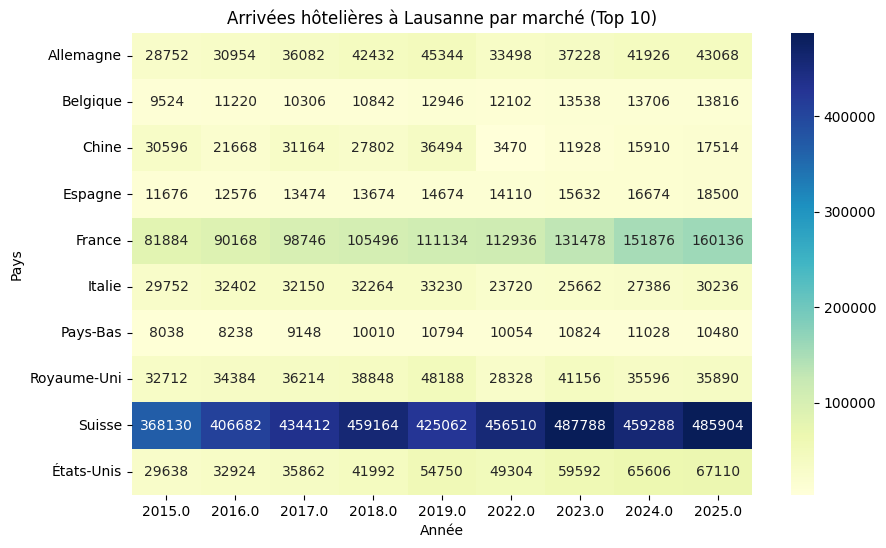

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché (Top 10)")
plt.ylabel("Pays")
plt.xlabel("Année")

plt.show()

moyenne de toutes les années

/tmp/ipykernel_409/1535865149.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_month["Mois"] = pd.Categorical(
/tmp/ipykernel_409/1535865149.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat = lausanne_month.groupby(["Pays","Mois"])["Arrivées"].mean().reset_index()


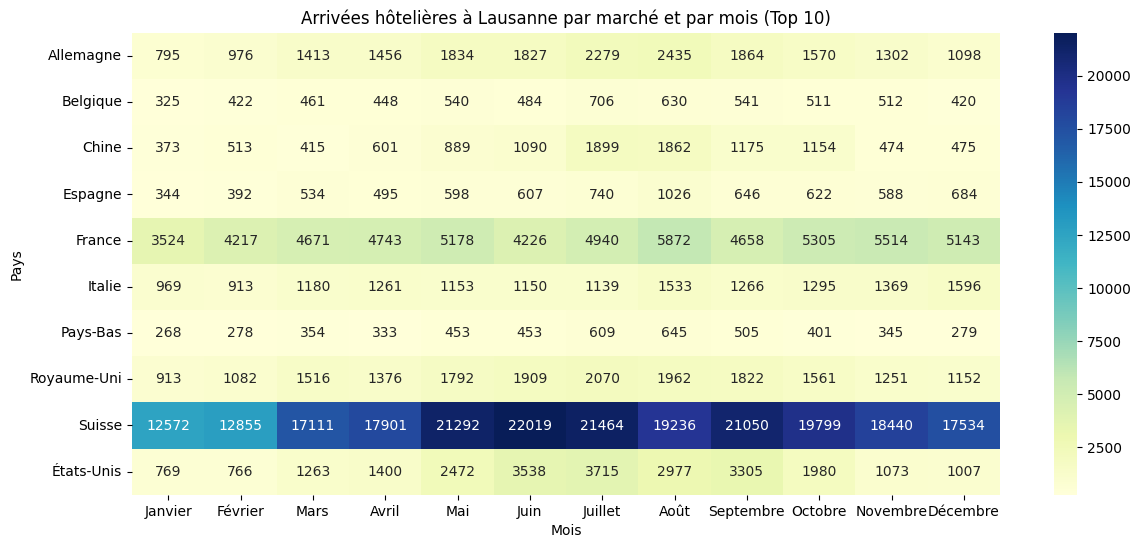

In [74]:
# 1️⃣ enlever les totaux annuels
lausanne_month = lausanne_top[lausanne_top["Mois"] != "Total de l'année"]

# 2️⃣ ordre correct des mois
month_order = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_month["Mois"] = pd.Categorical(
    lausanne_month["Mois"],
    categories=month_order,
    ordered=True
)

# 3️⃣ moyenne des arrivées par mois et par pays
lausanne_heat = lausanne_month.groupby(["Pays","Mois"])["Arrivées"].mean().reset_index()

# 4️⃣ pivot table
heatmap_data = lausanne_heat.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# 5️⃣ heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (Top 10)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2022

/tmp/ipykernel_409/4246778726.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2022["Mois"] = pd.Categorical(
/tmp/ipykernel_409/4246778726.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2022 = lausanne_2022.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


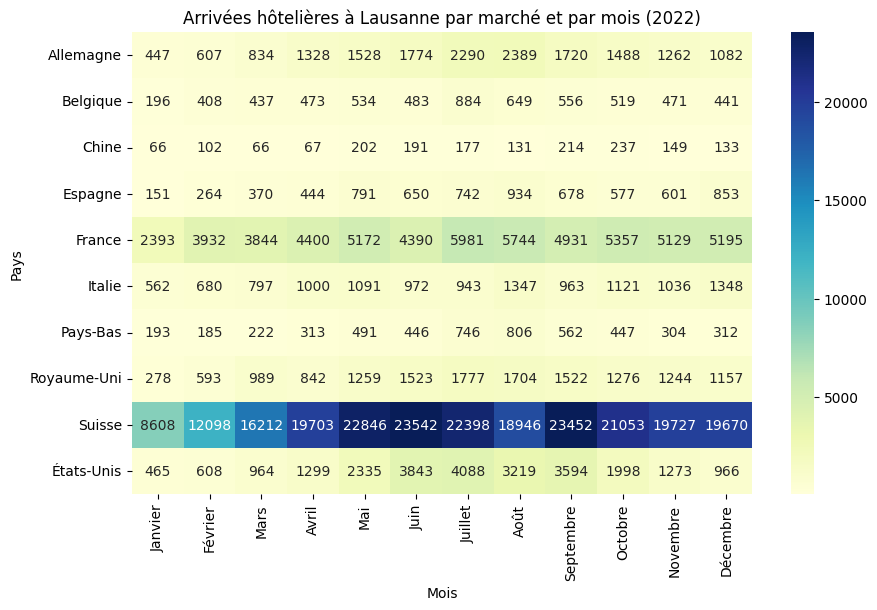

In [75]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2022
lausanne_2022 = lausanne_top[lausanne_top["Année"] == 2022]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2022["Mois"] = pd.Categorical(
    lausanne_2022["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2022 = lausanne_2022.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2022 = lausanne_heat_2022.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2022,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2022)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2023

/tmp/ipykernel_409/700287444.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2023["Mois"] = pd.Categorical(
/tmp/ipykernel_409/700287444.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2023 = lausanne_2023.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


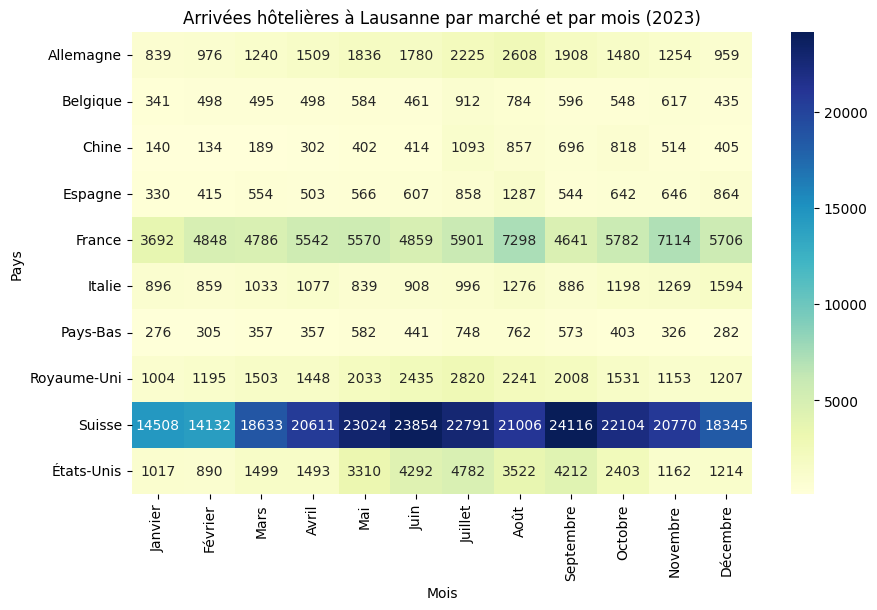

In [76]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2023
lausanne_2023 = lausanne_top[lausanne_top["Année"] == 2023]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2023["Mois"] = pd.Categorical(
    lausanne_2023["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2023 = lausanne_2023.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2023 = lausanne_heat_2023.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2023,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2023)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

graphes analyse clients par nationnalité 2024

/tmp/ipykernel_409/164388802.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_2024["Mois"] = pd.Categorical(
/tmp/ipykernel_409/164388802.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lausanne_heat_2024 = lausanne_2024.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()


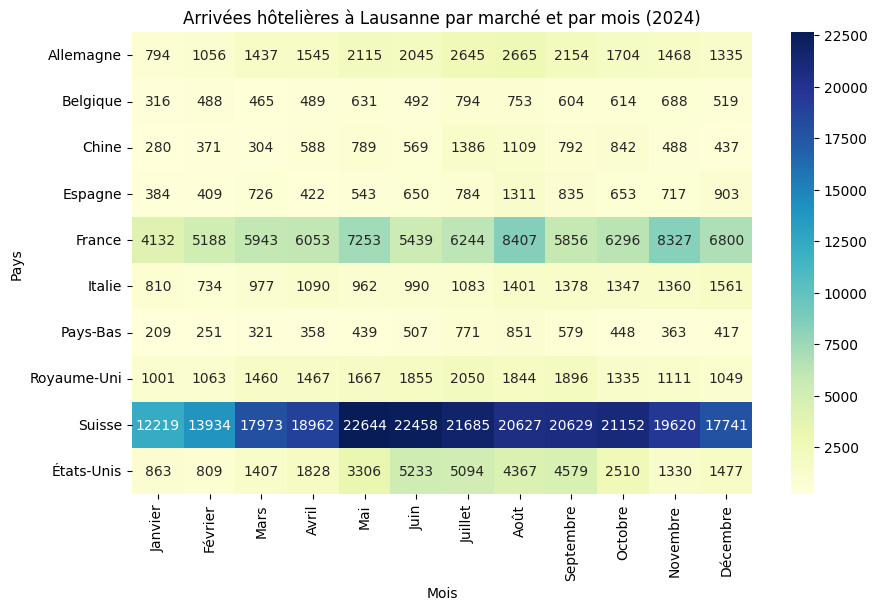

In [77]:
# Filtrer Lausanne
lausanne_df = df_tidy[df_tidy["Commune_nom"] == "Lausanne"]

# garder seulement les top 10 marchés
lausanne_top = lausanne_df[lausanne_df["Pays"].isin(top_markets)]

# filtrer uniquement l'année 2024
lausanne_2024 = lausanne_top[lausanne_top["Année"] == 2024]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_2024["Mois"] = pd.Categorical(
    lausanne_2024["Mois"],
    categories=mois_ordre,
    ordered=True
)

# préparation heatmap
lausanne_heat_2024 = lausanne_2024.groupby(["Pays","Mois"])["Arrivées"].sum().reset_index()

heatmap_2024 = lausanne_heat_2024.pivot(
    index="Pays",
    columns="Mois",
    values="Arrivées"
)

# graphique
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_2024,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Arrivées hôtelières à Lausanne par marché et par mois (2024)")
plt.ylabel("Pays")
plt.xlabel("Mois")

plt.show()

evolution des fréquentation par nationnalité

/tmp/ipykernel_409/430932921.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lausanne_recent["Mois"] = pd.Categorical(


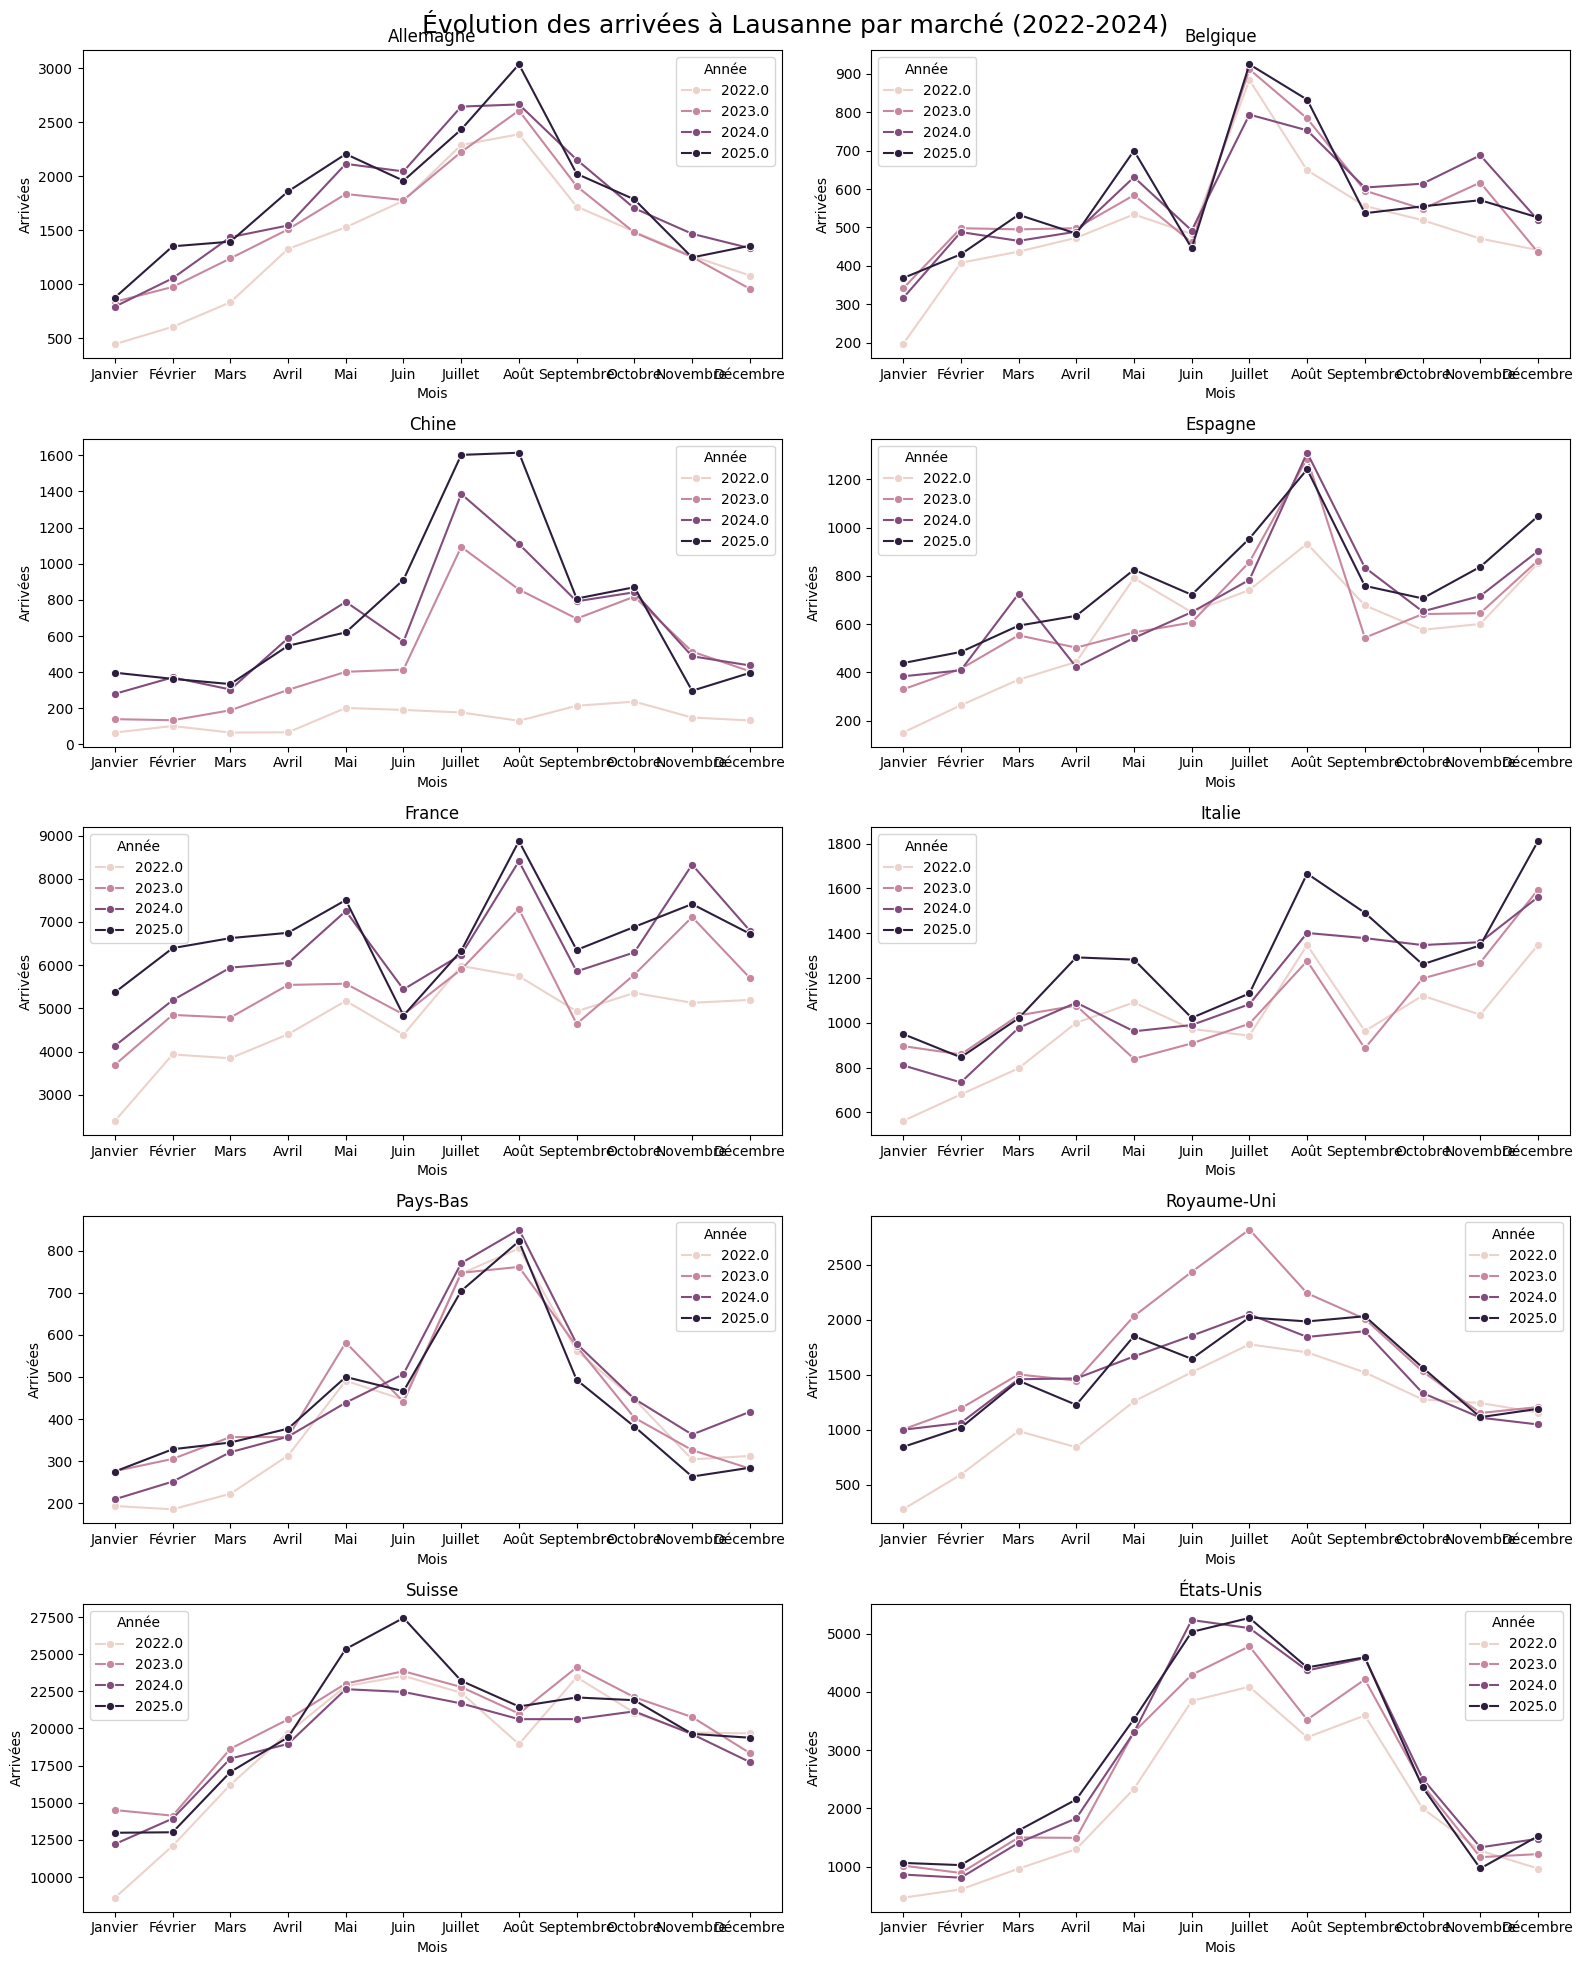

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# garder uniquement les années récentes
lausanne_recent = lausanne_top[lausanne_top["Année"].isin([2022, 2023, 2024, 2025])]

# ordre des mois
mois_ordre = [
    "Janvier","Février","Mars","Avril","Mai","Juin",
    "Juillet","Août","Septembre","Octobre","Novembre","Décembre"
]

lausanne_recent["Mois"] = pd.Categorical(
    lausanne_recent["Mois"],
    categories=mois_ordre,
    ordered=True
)

# liste des marchés
markets = lausanne_recent["Pays"].unique()

# création des 10 graphes
fig, axes = plt.subplots(5, 2, figsize=(16,20))
axes = axes.flatten()

for i, market in enumerate(markets):

    data_market = lausanne_recent[lausanne_recent["Pays"] == market]

    sns.lineplot(
        data=data_market,
        x="Mois",
        y="Arrivées",
        hue="Année",
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(market)
    axes[i].set_ylabel("Arrivées")
    axes[i].set_xlabel("Mois")

plt.suptitle("Évolution des arrivées à Lausanne par marché (2022-2024)", fontsize=18)
plt.tight_layout()
plt.show()